# Grocery Planning

Analyze your eating patterns and generate smart grocery lists with recommended quantities and purchase frequency.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from load_data import load_nutrition
from grocery_planning import top_groceries, purchase_recommendations, shopping_estimate, categorize_by_section
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
nutrition = load_nutrition()
print(f"Loaded {len(nutrition)} food entries for grocery analysis")

Loaded 2767 food entries for grocery analysis


## Top Ingredients by Frequency

In [3]:
# Get top groceries (last 30 days)
groceries = top_groceries(nutrition, top_n=20, days=30)

# Create DataFrame for display
grocery_df = pd.DataFrame([
    {
        'Food': g['food'],
        'Times Eaten': g['frequency'],
        'Total (g)': f"{g['total_weight_g']:.0f}",
        'Avg Serving (g)': f"{g['avg_serving_g']:.0f}",
        'Per Day (g)': f"{g['per_day_g']:.0f}"
    }
    for g in groceries
])

print("Top 20 Foods Eaten (Last 30 Days)")
print(grocery_df.to_string(index=False))

Top 20 Foods Eaten (Last 30 Days)
                                       Food  Times Eaten Total (g) Avg Serving (g) Per Day (g)
            Reduced Fat Ultra-Filtered Milk           20      4054             203         135
                              Banana, Fresh           17      2015             119          67
                       Creatine Monohydrate           13        71               5           2
       Elite Whey Protein Isolate Chocolate           11       402              37          13
                        Ultra-Filtered Milk           11      2507             228          84
   Free Range Large Brown Eggs With Omega-3            9       450              50          15
                   Carb Balance Whole Wheat            8       344              43          11
        Super Sizzle Extra Virgin Olive Oil            8        43               5           1
                                     Orange            7      1365             195          46
                

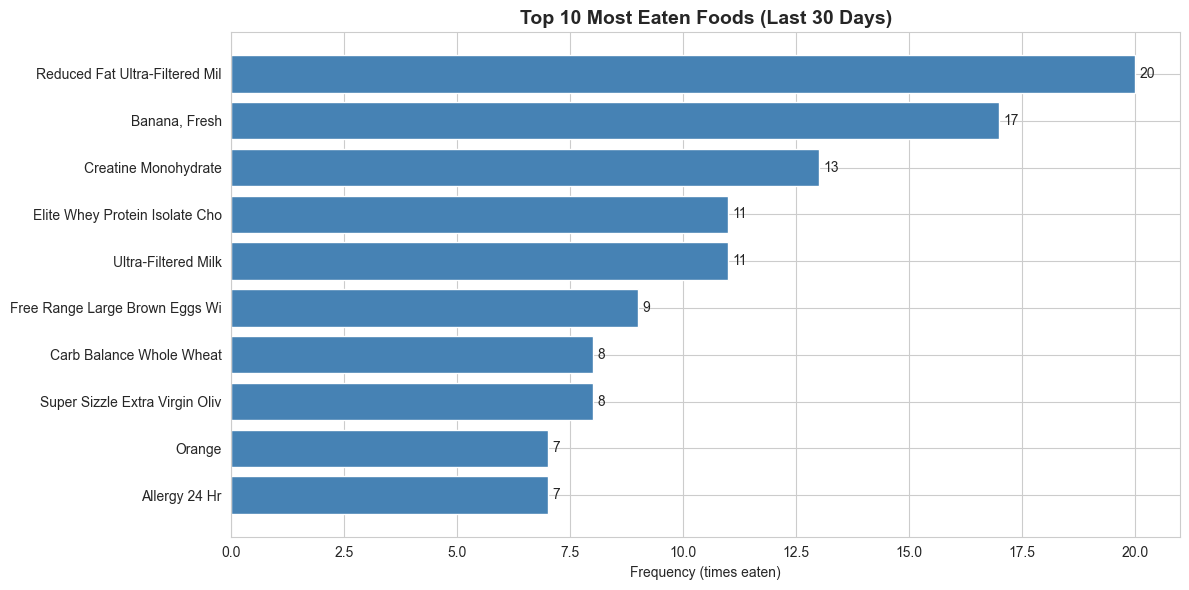

In [4]:
# Visualize top foods
top_10 = groceries[:10]
foods = [g['food'][:30] for g in top_10]  # Truncate long names
frequencies = [g['frequency'] for g in top_10]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(foods, frequencies, color='steelblue')
ax.set_xlabel('Frequency (times eaten)')
ax.set_title('Top 10 Most Eaten Foods (Last 30 Days)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(frequencies):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

## Smart Shopping Lists by Section

In [5]:
# Get purchase recommendations
recs = purchase_recommendations(nutrition, days=30)
summary = shopping_estimate(recs)

print(f"Grocery Planning Summary:")
print(f"  Weekly items: {summary['weekly_items']}")
print(f"  Bi-weekly items: {summary['biweekly_items']}")
print(f"  Monthly items: {summary['monthly_items']}")
print(f"  Total unique items: {summary['total_items']}")

Grocery Planning Summary:
  Weekly items: 4
  Bi-weekly items: 3
  Monthly items: 10
  Total unique items: 17


In [6]:
# Weekly items
if recs['weekly']:
    weekly_df = pd.DataFrame([
        {
            'Item': item['item'],
            'Frequency': item['frequency'],
            'Buy': f"{item['amount_to_buy']:.0f}g"
        }
        for item in recs['weekly']
    ])
    
    print("\nWeekly Shopping List:")
    print(weekly_df.to_string(index=False))
else:
    print("No weekly items identified")


Weekly Shopping List:
                                    Item  Frequency  Buy
         Reduced Fat Ultra-Filtered Milk         20 946g
                     Ultra-Filtered Milk         11 585g
Free Range Large Brown Eggs With Omega-3          9 105g
                          Oat Milk Latte          7 100g


In [7]:
# Bi-weekly items
if recs['biweekly']:
    biweekly_df = pd.DataFrame([
        {
            'Item': item['item'],
            'Frequency': item['frequency'],
            'Buy': f"{item['amount_to_buy']:.0f}g"
        }
        for item in recs['biweekly']
    ])
    
    print("\nBi-Weekly Shopping List:")
    print(biweekly_df.to_string(index=False))
else:
    print("No bi-weekly items identified")


Bi-Weekly Shopping List:
             Item  Frequency   Buy
    Banana, Fresh         17 1008g
           Orange          7  682g
100% Orange Juice          5  626g


In [8]:
# Monthly items
if recs['monthly']:
    monthly_df = pd.DataFrame([
        {
            'Item': item['item'],
            'Frequency': item['frequency'],
            'Buy': f"{item['amount_to_buy']:.0f}g"
        }
        for item in recs['monthly']
    ])
    
    print("\nMonthly Shopping List:")
    print(monthly_df.to_string(index=False))
else:
    print("No monthly items identified")


Monthly Shopping List:
                                       Item  Frequency   Buy
                       Creatine Monohydrate         13   71g
       Elite Whey Protein Isolate Chocolate         11  402g
                   Carb Balance Whole Wheat          8  344g
        Super Sizzle Extra Virgin Olive Oil          8   43g
                              Allergy 24 Hr          7  700g
Huel Ready-to-Drink Black Edition Chocolate          7 3500g
                               Jasmine Rice          6 1268g
                                  Olive Oil          6   45g
                      Thick Dried Bean Curd          6  663g
                            Super Seed Trio          6  132g


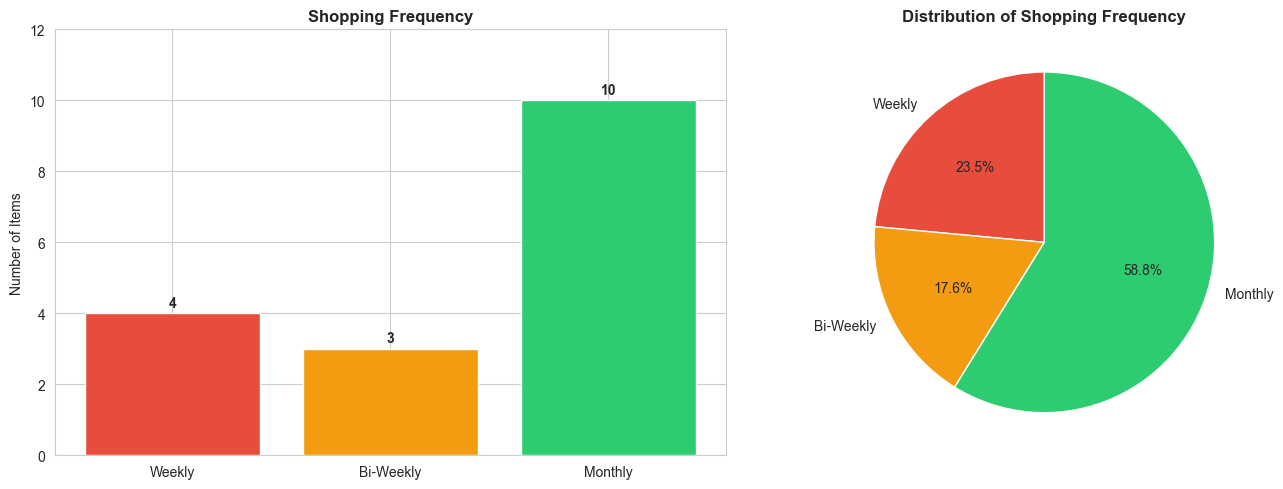

In [9]:
# Visualize shopping frequency
frequencies = ['Weekly', 'Bi-Weekly', 'Monthly']
counts = [summary['weekly_items'], summary['biweekly_items'], summary['monthly_items']]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(frequencies, counts, color=colors)
ax1.set_ylabel('Number of Items')
ax1.set_title('Shopping Frequency', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(counts) + 2)

for i, v in enumerate(counts):
    ax1.text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax2.pie(counts, labels=frequencies, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Distribution of Shopping Frequency', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
print("""
Shopping Tips Based on Your Data:

1. WEEKLY ITEMS (Perishables)
   - Buy fresh and use within the week
   - Items: milk, eggs, meats, fresh produce
   - Pro tip: Buy only what you'll eat in 7 days to minimize waste

2. BI-WEEKLY ITEMS (Semi-Perishables)
   - Eat moderately, buy every 2 weeks
   - Items: bread, most vegetables, berries
   - Pro tip: Store in optimal conditions (fridge/freezer) for longevity

3. MONTHLY ITEMS (Shelf-Stable)
   - Buy in bulk, lasts the whole month
   - Items: nuts, dried goods, pantry staples
   - Pro tip: Buy bulk sizes for non-perishables—better value

4. GENERAL ADVICE
   - Based on your consumption, adjust quantities by ±20% seasonally
   - Keep a running list and check it before shopping
   - Consider meal planning to reduce impulse purchases
   - Track spending to optimize your grocery budget
""")


Shopping Tips Based on Your Data:

1. WEEKLY ITEMS (Perishables)
   - Buy fresh and use within the week
   - Items: milk, eggs, meats, fresh produce
   - Pro tip: Buy only what you'll eat in 7 days to minimize waste

2. BI-WEEKLY ITEMS (Semi-Perishables)
   - Eat moderately, buy every 2 weeks
   - Items: bread, most vegetables, berries
   - Pro tip: Store in optimal conditions (fridge/freezer) for longevity

3. MONTHLY ITEMS (Shelf-Stable)
   - Buy in bulk, lasts the whole month
   - Items: nuts, dried goods, pantry staples
   - Pro tip: Buy bulk sizes for non-perishables—better value

4. GENERAL ADVICE
   - Based on your consumption, adjust quantities by ±20% seasonally
   - Keep a running list and check it before shopping
   - Consider meal planning to reduce impulse purchases
   - Track spending to optimize your grocery budget

